In [90]:
# One VS One(OvO):Class 1 vs 2, Class 1 vs 3, and Class 2 vs 3. Each classifier casts a vote, and the class with the most votes wins.
# One VS Rest(OvR):Classifier 1 separates Class 1 from Classes 2 & 3; Classifier 2 separates Class 2 from 1 & 3; Classifier 3 separates Class 3 from 1 & 2. The model predicts the class with the highest confidence score.

In [91]:
from sklearn import datasets
import pandas as pd
iris=datasets.load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [92]:
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [93]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [94]:
X=df[['sepal length (cm)','sepal width (cm)']]
# decisionboundarydisplay must be drawn on the 2D plane, so we only use two features for visualization.
y=df['target']
X.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [95]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

test report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45

train report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       0.71      0.81      0.76        37
           2       0.78      0.68      0.72        37

    accuracy                           0.82       105
   macro avg       0.83      0.83      0.83       105
weighted avg       0.82      0.82      0.82       105



/Users/xiaoying/Desktop/machinelearning/venv/lib/python3.14/site-packages/sklearn/inspection/_plot/decision_boundary.py:392: UserWarning: 'cmap' is ignored in favor of 'multiclass_colors' in the multiclass case.
  warnings.warn(


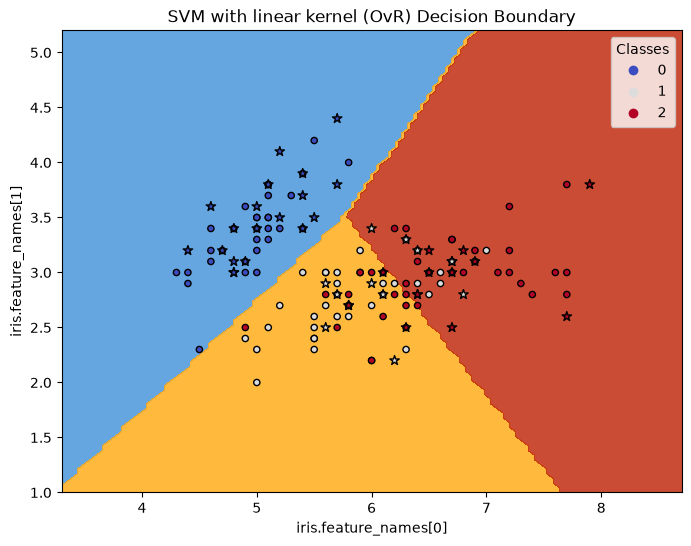

In [ ]:
from sklearn.svm import SVC
svm_model1=SVC(kernel='linear',C=1.0,decision_function_shape='ovr')
# decision_function_shape='ovr' means One-vs-Rest: It determines how the model formats its confidence scores or decision boundaries when dealing with multi-class classification
# returns an output array with the shape (n_samples, n_classes)—meaning one score for each class per sample.
# Each score represents how strongly a sample belongs to that specific class versus all the other classes combined.
svm_model1.fit(X_train,y_train)
y_predict_ovr_test=svm_model1.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print('test report\n',classification_report(y_test,y_predict_ovr_test))

y_predict_ovr_train=svm_model1.predict(X_train)
print("train report\n", classification_report(y_train,y_predict_ovr_train))

from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(8,6))
# use X_train and y_train to plot the decision surface because the primary goal of the plot is to display the learned decision boundaries and training support vectors, not to measure test generalization performance
# SVMs rely explicitly on support vectors—the specific data points from the training set that define the margins and position of the hyperplane. 
DecisionBoundaryDisplay.from_estimator(svm_model1,X_train,ax=ax,cmap=plt.cm.coolwarm,alpha=0.8,response_method='predict',)
# shows the predicted class labels for each point in the grid, allowing us to visualize how the SVM model separates the different classes in the feature space.

scatter_train=ax.scatter(X_train.iloc[:,0],X_train.iloc[:,1],c=y_train,cmap=plt.cm.coolwarm,edgecolors='k',s=20)
scatter_test=ax.scatter(X_test.iloc[:,0],X_test.iloc[:,1],c=y_test,cmap=plt.cm.coolwarm,edgecolors='k',s=50,marker='*')

ax.set_xlabel('iris.feature_names[0]')
ax.set_ylabel('iris.feature_names[1]')
ax.set_title('SVM with linear kernel (OvR) Decision Boundary')
ax.legend(*scatter_train.legend_elements(),title='Classes')

In [ ]:
# ovr is ovo under the hood, but it is more efficient to use ovr for multi-class classification. 
# The reason is that ovr trains fewer classifiers than ovo. For example, if you have 3 classes, ovr trains 3 classifiers (one for each class), while ovo trains 3 classifiers (one for each pair of classes). However, as the number of classes increases, the number of classifiers in ovo grows quadratically (n(n-1)/2), while in ovr it grows linearly (n). Therefore, ovr is generally more efficient for multi-class problems with many classes.
# LinearSVC is true OvR while OneVsRestClassifier is a wrapper for ovo estimator to make it OvR.
svm_model2=SVC(kernel='linear',C=1.0,decision_function_shape='ovo')
svm_model2.fit(X_train,y_train)
y_predict_ovo_train=svm_model2.predict(X_train)
print("train report", classification_report(y_train,y_predict_ovo_train))
y_predict_ovo_test=svm_model2.predict(X_test)
print("test report", classification_report(y_test,y_predict_ovo_test))

train report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       0.71      0.81      0.76        37
           2       0.78      0.68      0.72        37

    accuracy                           0.82       105
   macro avg       0.83      0.83      0.83       105
weighted avg       0.82      0.82      0.82       105

test report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45

